# Build Coupled Wflow-SFINCS Model


In [ ]:
from os.path import join
from copy import deepcopy
import os
from pathlib import Path
import sys

os.environ.pop("DEBUG", None)
from study_location import bootstrap
session = bootstrap()
location_root = session.location_root
repo_root = session.repo_root
for module_name in list(sys.modules):
    if module_name == "study_location" or module_name.startswith(("design_events", "sfincs_runs", "wflow_runs")):
        sys.modules.pop(module_name, None)

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pandas as pd
import yaml
from hydromt_sfincs import SfincsModel

# build domains, source points, observations, and physics checks.
import sfincs_runs.inland_base as inland_sfincs
from sfincs_runs.build_base import (
    plan_inland_sfincs_domain_set,
    plot_sfincs_handoff_basemap,
    sfincs_rivers_inflow_geoms,
    set_observations,
    write_inland_sfincs_domain_set_manifest,
)
# create native submodels and verify coupling inputs.
from wflow_runs import (
    coupled_domain_review,
    wflow_artifact_inventory,
    wflow_handoff_contract,
    build_wflow_data_catalog,
    build_wflow_submodel,
    wflow_catalog_source_readiness,
    write_wflow_domain_set_manifest,
)
from wflow_runs.reservoirs import validate_wflow_reservoir_staticmaps
# standard paths and readiness tables.
from wflow_runs.notebook import load_runtime, domain_summary

def configread(path):
    with open(path, encoding="utf-8") as handle:
        return yaml.safe_load(handle)

In [ ]:
# Load this Location Workspace.
runtime = load_runtime(Path("../..").resolve(), wflow_domain_review_required=True)
location_root = runtime.location_root
repo_root = runtime.repo_root
location_name = runtime.location_name
config = runtime.config
paths = runtime.design_paths

def location_path(value):
    return runtime.resolve_location_path(value)

sfincs_data_catalog = location_root / "data/static/data_catalogue.yaml"
wflow_data_catalog = runtime.wflow_base_root.parent / "data_catalog.yml"
wflow_base_root = runtime.wflow_base_root
wflow_network_path = Path(paths["usgs_streamgage_network_geojson"])

## Rerun Control


In [ ]:
rerun = True

## Coupled Domain Plan

Wflow is hydrologic coverage of watershed and extends upstream.

SFINCS is hydraulic coverage around each SMART-DS component.


### Wflow watershed and SFINCS coverage plans


In [ ]:
wflow_first_config = deepcopy(config)
wflow_first_config.setdefault("wflow", {}).setdefault("domain_set", {})["ignore_sfincs_handoff_artifacts"] = True
_, wflow_domain_plan, _ = domain_summary(wflow_first_config, location_root)
sfincs_domain_plan = plan_inland_sfincs_domain_set(config, paths)

if wflow_domain_plan.status != "ready":
    raise RuntimeError(f"Candidate Wflow Domain Set requires review before Wflow build: {wflow_domain_plan.status}: {wflow_domain_plan.issues}")
if sfincs_domain_plan.status != "ready":
    raise RuntimeError(f"SFINCS coverage domains require review before build: {sfincs_domain_plan.status}: {sfincs_domain_plan.issues}")

write_inland_sfincs_domain_set_manifest(sfincs_domain_plan, config, paths)
write_wflow_domain_set_manifest(wflow_domain_plan, wflow_first_config, paths)
domain_set = yaml.safe_load(location_path(config["sfincs_domain_set"]["domain_manifest"]).read_text())
sfincs_domains = list(domain_set["domains"])
selected_submodels = list(wflow_domain_plan.submodels)

### Candidate hydrologic boundary and handoff map

selected_source_subregion_ids
exposure_subregion_id


In [ ]:
domain_review = coupled_domain_review(
    wflow_first_config,
    location_root,
    sfincs_domains=sfincs_domains,
    wflow_domain_plan=wflow_domain_plan,
    figsize=(9, 7),
)

sfincs_domain_gdf = domain_review.sfincs_domain_gdf
plt.show()

HydroMT-Wflow needs the local DEM-derived hydrography basemap, landcover, soil parameter maps, and event forcing sources before the submodels can be built.

In [ ]:
wflow_catalog_path = build_wflow_data_catalog(config, paths)
wflow_source_readiness = pd.DataFrame(wflow_catalog_source_readiness(wflow_catalog_path))
missing_required_wflow_source = (
    wflow_source_readiness["required_for_build"].fillna(False).astype(bool)
    & wflow_source_readiness["local_file"].fillna(False).astype(bool)
    & ~wflow_source_readiness["exists"].fillna(False).astype(bool)
)
required_wflow_sources_missing = wflow_source_readiness[missing_required_wflow_source]

if not required_wflow_sources_missing.empty:
    missing_lines = [
        f"{row.source}: {row.uri}"
        for row in required_wflow_sources_missing.itertuples(index=False)
    ]
    display(wflow_source_readiness)
    raise FileNotFoundError(
        "Missing required HydroMT-Wflow source files before build:\n"
        + "\n".join(missing_lines)
        + f"\nRun locations/{location_name}/02_flood/01_region_setup.ipynb through the Terrain, Landcover, and Wflow static inputs cell first. "
        + "For a fresh Wflow static pull, launch that notebook with FLOOD_RM_FETCH_DEM=1; landcover fetch is enabled by default."
    )

wflow_source_readiness

In [7]:
wf_config = configread(str(location_path(config["wflow"]["build_config"])))
print(wf_config.keys())
pd.DataFrame({"step": [next(iter(step)) for step in wf_config.get("steps", [])]})

dict_keys(['steps'])


,step
0,setup_config
1,setup_basemaps
2,setup_rivers
3,setup_reservoirs_no_control
4,setup_lulcmaps
5,setup_soilmaps
6,setup_constant_pars
7,setup_gauges


### Build or reuse Wflow submodels before SFINCS handoff placement

SFINCS handoff sources are derived from built Wflow rivers.

In [ ]:
# First Wflow build: ignore any stale SFINCS handoff source artifacts so HydroMT-Wflow
# builds the hydrologic domain from the configured boundary-handoff subbasin plan.
wflow_native_build_summary = [
    build_wflow_submodel(
        wflow_first_config,
        paths,
        submodel_id=submodel["wflow_submodel_id"],
        force=rerun,
        write_catalog=False,
    )
    for submodel in selected_submodels
]

wflow_models = {summary["wflow_submodel_id"]: summary["model"] for summary in wflow_native_build_summary}

import numpy as np
from matplotlib import colors
from matplotlib.lines import Line2D

for summary in wflow_native_build_summary:
    staticmaps = summary["model"].staticmaps.data
    required = ("meta_upstream_area", "meta_streamorder", "local_drain_direction")
    missing = [name for name in required if name not in staticmaps]
    if missing:
        raise KeyError(f"staticmaps missing LDD QA variables: {missing}")

    layers = {}
    for name in required:
        layer = staticmaps[name]
        try:
            layer = layer.raster.mask_nodata()
        except Exception:
            fill_value = layer.attrs.get("_FillValue")
            if fill_value is not None:
                layer = layer.where(layer != fill_value)
        layers[name] = layer.where(layer > 0)

    crs = staticmaps.raster.crs
    is_geographic = bool(getattr(crs, "is_geographic", False)) or str(crs).upper() == "EPSG:4326"
    x_label = "longitude [degree east]" if is_geographic else "x"
    y_label = "latitude [degree north]" if is_geographic else "y"

    stream_values = np.asarray(layers["meta_streamorder"].values, dtype=float)
    stream_values = stream_values[np.isfinite(stream_values)]
    present_orders = sorted({int(value) for value in stream_values if float(value).is_integer()})
    visible_orders = [level for level in present_orders if level >= max(2, max(present_orders, default=0) - 3)]

    fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
    axes[0, 0].set_facecolor("white")
    basins = summary["model"].basins
    if basins is not None and not basins.empty:
        basins.to_crs(crs).boundary.plot(ax=axes[0, 0], color="black", linewidth=0.8, zorder=20)
    stream_palette = {1: "#00A6D6", 2: "#0057FF", 3: "#0040B8", 4: "#2E2E8B"}
    handles = []
    for level in visible_orders:
        color = stream_palette.get(level, "#003399")
        layers["meta_streamorder"].where(layers["meta_streamorder"] == level).plot(
            ax=axes[0, 0],
            cmap=colors.ListedColormap([color]),
            add_colorbar=False,
            zorder=4 + level,
        )
        handles.append(Line2D([0], [0], color=color, linewidth=2, label=f"strord={level}"))
    axes[0, 0].set_title("Selected stream order")
    if handles:
        axes[0, 0].legend(handles=handles, title="Stream order", loc="lower right")

    np.log10(layers["meta_upstream_area"]).plot(
        ax=axes[0, 1],
        cmap="viridis",
        cbar_kwargs=dict(shrink=0.75, label="log10 upstream area [km2]"),
    )
    axes[0, 1].set_title("upstream area")

    layers["meta_streamorder"].plot(
        ax=axes[1, 0],
        cmap="magma",
        cbar_kwargs=dict(shrink=0.75, label="stream order"),
    )
    axes[1, 0].set_title("meta_streamorder")

    ldd_values = np.asarray(layers["local_drain_direction"].values, dtype=float)
    ldd_values = ldd_values[np.isfinite(ldd_values)]
    ldd_codes = sorted({int(value) for value in ldd_values if float(value).is_integer()})
    if ldd_codes and max(ldd_codes) <= 9:
        ldd_cmap = colors.ListedColormap(plt.cm.tab10(np.linspace(0, 1, 9)))
        ldd_norm = colors.BoundaryNorm(np.arange(0.5, 10.5, 1), ldd_cmap.N)
        ldd_ticks = range(1, 10)
        ldd_label = "LDD code"
    else:
        ldd_cmap = colors.ListedColormap(plt.cm.tab20(np.linspace(0, 1, 8)))
        ldd_norm = colors.BoundaryNorm([0.5, 1.5, 3, 6, 12, 24, 48, 96, 192], ldd_cmap.N)
        ldd_ticks = [1, 2, 4, 8, 16, 32, 64, 128]
        ldd_label = "D8 code"
    layers["local_drain_direction"].plot(
        ax=axes[1, 1],
        cmap=ldd_cmap,
        norm=ldd_norm,
        cbar_kwargs=dict(shrink=0.75, label=ldd_label, ticks=list(ldd_ticks)),
    )
    axes[1, 1].set_title("local_drain_direction")

    for ax in axes.ravel():
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
    fig.savefig(wflow_base_root / summary["wflow_submodel_id"] / "wflow_ldd_components.png", dpi=300, bbox_inches="tight")

pd.DataFrame([
    {k: v for k, v in summary.items() if k != "model"}
    for summary in wflow_native_build_summary
])

### Initialize SFINCS coverage models

discharge sources are added after Wflow-native rivers are available.


In [ ]:
sfincs_model_rows = [
    {
        "sfincs_domain_id": domain["sfincs_domain_id"],
        "region": str(location_path(domain["region"]).relative_to(repo_root)),
        "base_model_root": str(location_path(domain["base_model_root"]).relative_to(repo_root)),
        "handoff_source_count": len(domain["handoff_source_ids"]),
        "grid_resolution_m": float(config["sfincs"]["grid_resolution_m"]),
    }
    for domain in sfincs_domains
]

pd.DataFrame(sfincs_model_rows)

### SFINCS build config


In [10]:
sf_config_path = location_path(config["sfincs"]["build_config"])
sf_recipe = (config.get("_model_recipes") or {}).get("sfincs_build")
if sf_recipe is not None:
    sf_config_path.parent.mkdir(parents=True, exist_ok=True)
    sf_config_path.write_text(
        "# GENERATED FILE — do not edit. Overwritten when the sfincs_build model YAML extraction runs.\n"
        "# Source of truth is the location config and the code that produces this file.\n"
        + yaml.safe_dump(sf_recipe, sort_keys=False),
        encoding="utf-8",
    )
sf_config = configread(str(sf_config_path))
sf_config["setup_grid_from_region"]["res"] = config["sfincs"]["grid_resolution_m"]
sf_config["setup_grid_from_region"]["crs"] = config["sfincs"].get("model_crs", config["project"]["model_crs"])
sf_config["setup_dep"]["datasets_dep"] = [{"elevtn": "dem_region"}]
sf_config["setup_subgrid"]["datasets_dep"] = [{"elevtn": "dem_region"}]
sf_config["setup_subgrid"]["datasets_rgh"] = [{"lulc": "landcover_region"}]
sf_config.pop("setup_river_outflow", None)
print(sf_config.keys())

dict_keys(['setup_grid_from_region', 'setup_dep', 'setup_mask_active', 'setup_mask_bounds', 'setup_subgrid'])


In [ ]:
sfincs_build_report = inland_sfincs.build_domains(
    config,
    paths,
    force=rerun,
)

domain_set = yaml.safe_load(location_path(config["sfincs_domain_set"]["domain_manifest"]).read_text())
sfincs_domains = list(domain_set["domains"])

_, wflow_domain_plan, _ = domain_summary(config, location_root)
if wflow_domain_plan.status != "ready":
    raise RuntimeError(f"Wflow Domain Set requires review after built-river handoff build: {wflow_domain_plan.status}: {wflow_domain_plan.issues}")
write_wflow_domain_set_manifest(wflow_domain_plan, config, paths)
selected_submodels = list(wflow_domain_plan.submodels)

sfincs_models = {}
handoff_layers = []
for domain in sfincs_domains:
    domain_id = domain["sfincs_domain_id"]
    root = location_path(domain["base_model_root"])
    sf = SfincsModel(
        root=str(root),
        mode="r+",
        data_libs=[str(sfincs_data_catalog), str(wflow_data_catalog)],
    )
    sf.read()
    sfincs_models[domain_id] = sf
    handoff_layers.append(gpd.read_file(root / "gis/wflow_handoff_sources.geojson"))

sfincs_build_report

### SFINCS coverage plots

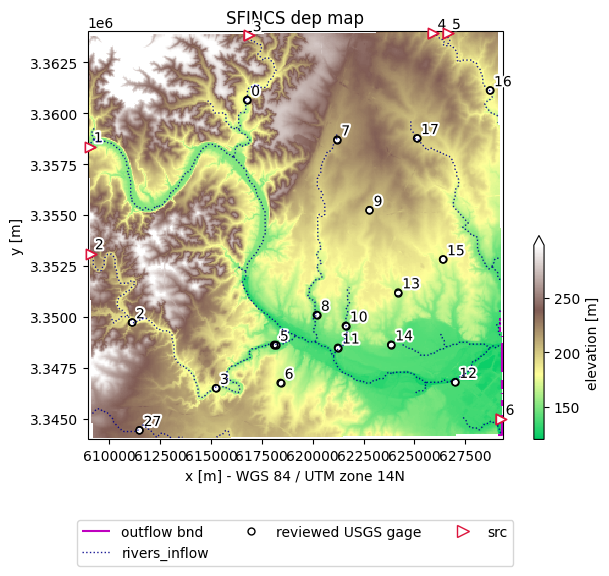

In [12]:
handoff_gdf = pd.concat(handoff_layers, ignore_index=True)
handoff_gdf = gpd.GeoDataFrame(handoff_gdf, geometry="geometry", crs=handoff_layers[0].crs)

for domain in sfincs_domains:
    domain_id = domain["sfincs_domain_id"]
    sf = sfincs_models[domain_id]
    sf.elevation.data["dep"].attrs.update(long_name="elevation", units="m")
    handoff_locations = location_path(domain["base_model_root"]) / "gis/wflow_handoff_sources.geojson"
    rivers = sfincs_rivers_inflow_geoms(sf)
    observations = gpd.GeoDataFrame(columns=["geometry"], geometry="geometry", crs=sf.crs)
    if wflow_network_path.exists():
        observations = set_observations(sf, wflow_network_path)
    fig, ax, plot_qa = plot_sfincs_handoff_basemap(
        sf,
        handoff_sources=handoff_locations,
        rivers=rivers,
        observations=observations,
        config=config,
        paths=paths,
        domain_region=domain["region"],
        figsize=(8, 6),
    )
    fig.savefig(join(sf.root.path, "sfincs_basemap.png"), dpi=450, bbox_inches="tight")

### SFINCS handoff source table

In [13]:
handoff_columns = [
    "sfincs_domain_id",
    "sfincs_handoff_id",
    "wflow_submodel_id",
    "site_no",
    "handoff_placement",
    "handoff_location_review_status",
    "stream_boundary_river_source",
    "stream_boundary_candidate_count",
]
handoff_columns = [column for column in handoff_columns if column in handoff_gdf.columns]
handoff_gdf[handoff_columns]

,sfincs_domain_id,sfincs_handoff_id,wflow_submodel_id,site_no,handoff_placement,handoff_location_review_status,stream_boundary_river_source,stream_boundary_candidate_count
0,austin_p5u,austin_p5u_inflow_01,austin_p5u,austin_p5u_inflow_01,stream_boundary_intersection,hydromt_wflow_native_stream_boundary_intersection,hydromt_wflow_setup_rivers,166
1,austin_p5u,austin_p5u_inflow_02,austin_p5u,austin_p5u_inflow_02,stream_boundary_intersection,hydromt_wflow_native_stream_boundary_intersection,hydromt_wflow_setup_rivers,166
2,austin_p5u,austin_p5u_inflow_03,austin_p5u,austin_p5u_inflow_03,stream_boundary_intersection,hydromt_wflow_native_stream_boundary_intersection,hydromt_wflow_setup_rivers,166
3,austin_p5u,austin_p5u_inflow_04,austin_p5u,austin_p5u_inflow_04,stream_boundary_intersection,hydromt_wflow_native_stream_boundary_intersection,hydromt_wflow_setup_rivers,166
4,austin_p5u,austin_p5u_inflow_05,austin_p5u,austin_p5u_inflow_05,stream_boundary_intersection,hydromt_wflow_native_stream_boundary_intersection,hydromt_wflow_setup_rivers,166
5,austin_p5u,austin_p5u_inflow_06,austin_p5u,austin_p5u_inflow_06,stream_boundary_intersection,hydromt_wflow_native_stream_boundary_intersection,hydromt_wflow_setup_rivers,166


### Build Wflow gauges at native SFINCS boundary sources

`setup_gauges` SFINCS layer reads exactly Wflow boundary-source points.

In [ ]:
reservoirs_enabled = bool(config.get("collection", {}).get("national_hydrography", {}).get("reservoirs", {}).get("enabled", False))
reservoir_preflight_rows = []
if reservoirs_enabled:
    for submodel in selected_submodels:
        submodel_id = submodel["wflow_submodel_id"]
        model_root = wflow_base_root / submodel_id
        staticmaps_path = model_root / "staticmaps.nc"
        if staticmaps_path.exists():
            report = validate_wflow_reservoir_staticmaps(model_root, required=True, raise_on_error=False)
            report.insert(0, "wflow_submodel_id", submodel_id)
            reservoir_preflight_rows.append(report)
    reservoir_preflight = pd.concat(reservoir_preflight_rows, ignore_index=True) if reservoir_preflight_rows else pd.DataFrame()
    display(reservoir_preflight)
    if not reservoir_preflight.empty and reservoir_preflight["status"].isin(["failed", "review_required"]).any() and not rerun:
        raise RuntimeError("Reservoirs are enabled, but the existing Wflow base is stale. Set rerun=True and rerun this step.")

wflow_build_summary = [
    build_wflow_submodel(
        config,
        paths,
        submodel_id=submodel["wflow_submodel_id"],
        force=rerun,
        write_catalog=False,
    )
    for submodel in selected_submodels
]

wflow_models = {summary["wflow_submodel_id"]: summary["model"] for summary in wflow_build_summary}
pd.DataFrame([{k: v for k, v in summary.items() if k != "model"} for summary in wflow_build_summary])

### Final coupled Wflow basemaps

Plot the native Wflow model with filled Wflow basin and SFINCS coverage areas, Wflow-native river vectors, intended SFINCS handoff sources, and the model's post-snap `gauges_sfincs` layer. This is the main check that the upstream Wflow model feeds the right hydraulic coverage box boundaries without confusing source artifacts with snapped Wflow gauge cells.


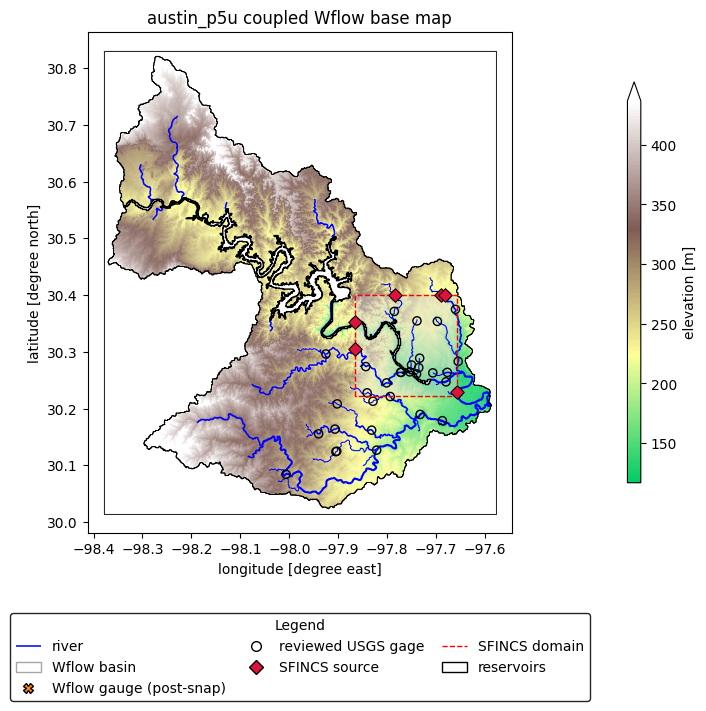

In [ ]:
sfincs_background_elevation = [sf.elevation.data["dep"] for sf in sfincs_models.values()]
for submodel_id, wf in wflow_models.items():
    staticmaps = wf.staticmaps.data
    map_crs = staticmaps.raster.crs
    elevation = staticmaps["land_elevation"].raster.mask_nodata()
    finite_elevation = np.asarray(elevation.values, dtype=float)
    finite_elevation = finite_elevation[np.isfinite(finite_elevation)]
    vmin, vmax = np.nanquantile(finite_elevation, [0.0, 0.98]) if finite_elevation.size else (None, None)
    dem_cmap = colors.LinearSegmentedColormap.from_list("wflow_dem", plt.cm.terrain(np.linspace(0.25, 1.0, 256)))

    fig, ax = plt.subplots(figsize=(9.5, 7.0), constrained_layout=True)
    for background in sfincs_background_elevation:
        try:
            background = background.raster.mask_nodata()
            if background.raster.crs != map_crs:
                background = background.raster.reproject(dst_crs=map_crs, method="bilinear")
            background.plot(ax=ax, cmap=dem_cmap, vmin=vmin, vmax=vmax, add_colorbar=False, zorder=0)
        except Exception:
            pass
    elevation.attrs.update(long_name="elevation", units="m")
    elevation.plot(ax=ax, cmap=dem_cmap, vmin=vmin, vmax=vmax, cbar_kwargs=dict(aspect=30, shrink=0.8, label="elevation [m]"))

    legend_handles = [Patch(facecolor="white", edgecolor="black", alpha=0.35, label="Wflow basin")]
    basins = wf.basins.to_crs(map_crs) if wf.basins.crs else wf.basins
    if basins is not None and not basins.empty:
        basins.plot(ax=ax, facecolor="white", edgecolor="black", alpha=0.12, linewidth=0.4, zorder=2)
        basins.boundary.plot(ax=ax, color="black", linewidth=0.6, zorder=5)

    domains = sfincs_domain_gdf.to_crs(map_crs) if sfincs_domain_gdf.crs else sfincs_domain_gdf
    if domains is not None and not domains.empty:
        domains.plot(ax=ax, facecolor="#d9d9d9", edgecolor="none", alpha=0.45, zorder=3)
        domains.boundary.plot(ax=ax, color="red", linewidth=1.0, linestyle="--", zorder=7)
        legend_handles.append(Line2D([0], [0], color="red", linewidth=1.0, linestyle="--", label="SFINCS domain"))

    rivers = wf.rivers.to_crs(map_crs) if wf.rivers.crs else wf.rivers
    if rivers is not None and not rivers.empty:
        if "strord" in rivers:
            stream_order = rivers["strord"].astype(float)
            keep = stream_order >= 2
            if domains is not None and not domains.empty:
                domain_union = domains.geometry.union_all() if hasattr(domains.geometry, "union_all") else domains.unary_union
                keep = keep | ((stream_order >= 1) & rivers.geometry.intersects(domain_union))
            rivers = rivers.loc[keep].copy()
            stream_order = stream_order.loc[rivers.index]
            linewidth = stream_order / max(float(stream_order.max()), 1.0) * 1.4 + 0.4
        else:
            linewidth = 1.0
        rivers.plot(ax=ax, color="blue", linewidth=linewidth, zorder=4)
        legend_handles.append(Line2D([0], [0], color="blue", linewidth=1.2, label="river"))

    observation_gages_path = wflow_base_root.parent / "domain_set_gauges" / f"{submodel_id}_observation_gauges.geojson"
    observation_gages = gpd.read_file(observation_gages_path) if observation_gages_path.exists() else None
    if observation_gages is not None and not observation_gages.empty:
        observation_gages = observation_gages.to_crs(map_crs) if observation_gages.crs else observation_gages
        observation_gages.plot(ax=ax, marker="o", markersize=35, facecolor="none", edgecolor="black", linewidth=1.0, zorder=7)
        legend_handles.append(Line2D([0], [0], marker="o", color="none", markerfacecolor="none", markeredgecolor="black", markersize=7, label="reviewed USGS gage"))

    handoff_sources = handoff_gdf.copy() if "handoff_gdf" in globals() else None
    if handoff_sources is not None and "wflow_submodel_id" in handoff_sources:
        handoff_sources = handoff_sources[handoff_sources["wflow_submodel_id"].astype(str).eq(str(submodel_id))]
    if handoff_sources is not None and not handoff_sources.empty:
        handoff_sources = handoff_sources.to_crs(map_crs) if handoff_sources.crs else handoff_sources
        handoff_sources.plot(ax=ax, marker="D", markersize=48, facecolor="crimson", edgecolor="black", linewidth=0.7, zorder=8)
        legend_handles.append(Line2D([0], [0], marker="D", color="none", markerfacecolor="crimson", markeredgecolor="black", markersize=7, label="SFINCS source"))

    xpad = (elevation.x.max() - elevation.x.min()) * 0.02
    ypad = (elevation.y.max() - elevation.y.min()) * 0.02
    ax.set_xlim(float(elevation.x.min() - xpad), float(elevation.x.max() + xpad))
    ax.set_ylim(float(elevation.y.min() - ypad), float(elevation.y.max() + ypad))
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("longitude [degree east]" if getattr(map_crs, "is_geographic", False) else "x")
    ax.set_ylabel("latitude [degree north]" if getattr(map_crs, "is_geographic", False) else "y")
    ax.set_title(f"{submodel_id} coupled Wflow base map")
    ax.legend(handles=legend_handles, title="Legend", loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=min(3, len(legend_handles)), frameon=True, framealpha=0.86)
    fig.savefig(wflow_base_root / submodel_id / "wflow_basemap.png", dpi=450, bbox_inches="tight")

### Wflow gauge QA

In [16]:
handoff_review = wflow_handoff_contract(
    config,
    location_root,
    wflow_models=wflow_models,
    handoff_gdf=handoff_gdf,
    wflow_base_root=wflow_base_root,
)

handoff_contract = handoff_review.handoff_contract
display(handoff_contract)
handoff_review.gauge_layers

,wflow_submodel_id,sfincs_handoff_id,wflow_gauge_index,wflow_gauge_handoff_id,source_to_wflow_gauge_m,wflow_input_to_source_m,source_count_per_wflow_gauge
0,austin_p5u,austin_p5u_inflow_01,None,austin_p5u_inflow_01,52.966,0.0,NaN
1,austin_p5u,austin_p5u_inflow_02,None,austin_p5u_inflow_02,52.977,0.0,NaN
2,austin_p5u,austin_p5u_inflow_03,None,austin_p5u_inflow_03,2.676,0.0,NaN
3,austin_p5u,austin_p5u_inflow_04,None,austin_p5u_inflow_04,2.677,0.0,NaN
4,austin_p5u,austin_p5u_inflow_05,None,austin_p5u_inflow_05,2.023,0.0,NaN
5,austin_p5u,austin_p5u_inflow_06,None,austin_p5u_inflow_06,9.225,0.0,NaN


,wflow_submodel_id,geometry_layer,feature_count
0,austin_p5u,gauges_sfincs,6
1,austin_p5u,subcatchment_sfincs,6
2,austin_p5u,gauges_usgs,31
